# 0605 디펜스 피드백

## error case 분석

### 모든 모델이 공통적으로 틀린 문제

In [ ]:
# 모든 모델에서 모두 틀린 케이스
import pandas as pd
# 1. gemma
result_df = pd.read_csv("/workspace/data/test_set_process/inference/wsd_set_entire_labeled_ambiguous_sentence_sense_search3_gemma-3-27b-it.csv")

for index, row in result_df.iterrows():
    pred_label = row["generated_text"].split("A:")[-1].strip().lower()
    mapped_label = int(pred_label)
    result_df.at[index, "predicted_label"] = mapped_label

gemma_wrong_cases = result_df[result_df["predicted_label"] != result_df["gold_sense"]]
gemma_wrong_cases = set(gemma_wrong_cases["word_index"].tolist())

# 2. qwen3
result_df = pd.read_csv("/workspace/data/test_set_process/inference/wsd_set_entire_labeled_ambiguous_sentence_sense_search4_qwen3-vl-30b-instruct.csv")

for index, row in result_df.iterrows():
    pred_label = row["generated_text"].split("A:")[-1].strip().lower()
    try:
        mapped_label = int(pred_label)
    except ValueError:
        mapped_label = -1  # 예외 처리: 정수로 변환할 수 없는 경우 -1로 설정
    result_df.at[index, "predicted_label"] = mapped_label

qwen_wrong_cases = result_df[result_df["predicted_label"] != result_df["gold_sense"]]
qwen_wrong_cases = set(qwen_wrong_cases["word_index"].tolist())

# 3. mistral-small-3.1
result_df = pd.read_csv("/workspace/data/test_set_process/inference/wsd_set_entire_labeled_ambiguous_sentence_sense_search3_mistral-small-3.csv")

for index, row in result_df.iterrows():
    pred_label = row["generated_text"].split("A:")[-1].strip().lower()
    try:
        mapped_label = int(pred_label)
    except ValueError:
        mapped_label = -1  # 예외 처리: 정수로 변환할 수 없는 경우 -1로 설정
    result_df.at[index, "predicted_label"] = mapped_label

mistral_wrong_cases = result_df[result_df["predicted_label"] != result_df["gold_sense"]]
mistral_wrong_cases = set(mistral_wrong_cases["word_index"].tolist())

# 세 집합의 교집합
all_wrong_cases = gemma_wrong_cases.intersection(qwen_wrong_cases).intersection(mistral_wrong_cases)
print("모든 모델에서 틀린 케이스의 word_index:", all_wrong_cases)

모든 모델에서 틀린 케이스의 word_index: {2, 454, 6, 335, 17, 276, 117, 57, 218, 446}


### 문제 분석

word_index: 2

word는 seat이고, 의자가 놓여있는 회화 그림. 정답 센스는 의자 가구를 뜻하는 센스 3. 이 센스가 가장 직접적으로 그림을 표현한다.

---

* gemma-3: web content 있음. 요약문에서 seat을 의자의 일부분인 '좌석'의 의미로 해석. 이에 따라 모델도 seat를 의자가 아닌 좌석으로 판별.
* qwen3: web content 있음. 요약문에서 단어 chair와 seat를 구분해서 사용. seat는 의자 자체가 아닌 좌석의 의미로 사용. 문장은 모호함. 이에 따라 모델은 seat를 의자라는 가구가 아닌 좌석을 뜻하는 4번 sense로 결정.
* mistral-small-3.1: web content 있음. 요약문에서 단어 chair와 seat를 구분해서 사용. seat는 의자 자체가 아닌 좌석의 의미로 사용. 문장은 모호함. 이에 따라 모델은 seat를 의자라는 가구가 아닌 좌석을 뜻하는 4번 sense로 결정.

RAG content에서 seat라는 단어를 사실상 '의자'라는 의미를 배제하고, '좌석'이라는 의미로 사용하며 강한 선입관을 부여. RAG이 결정을 방해

word_index: 6

word는 tympanum이고, 귀의 외이도를 나타낸 그림. 정답 센스는 고막보다는 고실 전체을 뜻하는 센스 1. 이 센스가 가장 직접적으로 그림을 표현한다.

asen: After the flight, my tympanum felt a little blocked.

---

* gemma-3: web content 있음. 요약문은 특정 sense와 직접 관련이 있다기보다는 배경 지식을 이야기함. 해당 배경지식이 의도한 센스가 아닌 2번 고막 센스에 더 가까운 context를 제공. 주어진 asen이 오답인 2번 sense를 너무 강하게 암시함.
* qwen3: web content 있음. 요약문은 특정 sense와 직접 관련이 있다기보다는 전체적인 배경 지식을 이야기함. 해당 배경지식이 의도한 센스가 아닌 2번 고막 센스에 더 가까운 context를 제공. asen이 오답인 2번 sense를 너무 강하게 암시함.
* mistral-small-3.1: web content 있음. 요약문은 특정 sense와 직접 관련이 있다기보다는 전체적인 배경 지식을 이야기함. 해당 배경지식이 의도한 센스가 아닌 2번 고막 센스에 더 가까운 context를 제공. asen이 오답인 2번 sense를 너무 강하게 암시함.

asen이 주는 강한 선입관이 예측을 방해. RAG은 별로 도움을 주지 못함.

word_index: 17

word는 metal이고, 계단 금속 질감을 클로즈업한 사진. 정답 합금을 뜻하는 센스 2.

asen: The jeweler recommended a metal for the bracelet that would keep its color.

---

* gemma-3: web content 없음. asen만 보고 어째서인지 추론 과정에서 합금보다 금속류 전체가 정답이라고 판단. context 부족. asen의 metal은 모호하며, 이미지가 합금이라는 사실을 알려주는 context가 없음
* qwen3: web content 없음. context 부족. asen의 metal은 모호하며, 이미지가 합금이라는 사실을 알려주는 context가 없음
* mistral-small-3.1: web content 있음. context 부족. asen의 metal은 모호하며, 이미지가 합금이라는 사실을 알려주는 context가 없음

context 부족. 이거는 RAG content가 이미지가 보여주는 것이 합금이라는 사실을 확인해 주어야 하는데 RAG content가 하나도 인용되지 않음.

word_index: 57

word는 try, 법원에서 판사가 망치 휘두르는 사진. 정답은 5.

asen: They will try the matter in court tomorrow.

---

* gemma-3: RAG content 있음. 헷갈리는 두 센스 중 어느 쪽이 이미지에 가장 적합한지 알려주는 context가 없음. asen은 모호.
* qwen3: RAG content 있음. 헷갈리는 두 센스 중 어느 쪽이 이미지에 가장 적합한지 알려주는 context가 없음. asen은 모호.
* mistral-small-3.1: RAG content 있음. 헷갈리는 두 센스 중 어느 쪽이 이미지에 가장 적합한지 알려주는 context가 없음. asen은 모호.

이미지에 가장 직접적인 것은 사건을 심리하는 action만을 뜻하는 5번이지만, asen이 주는 강한 선입관이 이미지와 align되어 '판사로서 사건을 심리하다'인 3번 sense를 강하게 push해버림. 가장 특정한 sense를 고르라는 지시 사항을 지키지 못함.

RAG이 포괄적인 재판에 관해 논의하며 sense를 특정한 action을 나타내는 5번보다 포괄적인 재판 주재를 의미하는 3번으로 기울어지게 만듬. RAG이 방해.
sense over-granularity

word_index: 117

word는 paper, 신문지가 가판대에 쌓여있는 사진. 정답은 7.

asen: I grabbed the paper before heading out.

---

* gemma-3: RAG content는 언론의 자유에 관한 포괄적인 뒷배경. 모델은 더 general한 sense인 3번을 택했지만, prompt에서는 가장 좁은 특정한 의미(specific)를 고르라고 하였으므로 7번이 정답. 프롬프트의 가장 특정한 것을 고르라는 말을 까먹은 것.
* qwen3: RAG content는 언론의 자유에 관한 포괄적인 뒷배경.추론 과정 없음. 그냥 3번.
* mistral-small-3.1: RAG content는 언론의 자유에 관한 포괄적인 뒷배경. RAG의 오류. 언론의 자유에 관한 내용인 RAG 내용이 sense를 신문지라는 좁은 sense보다 언론이라는 포괄적인 sesne에 더 가깝게 위치시킴

RAG 내용이 신문지보다는 포괄적인 언론에 관한 내용이라 3번에 더 sense를 가깝게 보냄. 가장 specific한 의미는 7번이지만, RAG이 방해함..

word_index: 218

word는 caper, 식물의 생태를 묘사한 그림. 정답은 1.

asen: At the market, I picked up a caper.

---

* gemma-3: RAG content는 caper가 식용으로 쓰이는 식물이라는 점을 강조. 모델은 이미지 context를 넘어 RAG을 따라 식용을 꽃봉우리를 뜻하는 2번 sense에 꽂힘.
* qwen3: RAG content는 caper가 식용으로 쓰이는 식물이라는 점을 강조. 모델은 이미지 context를 넘어 RAG을 따라 식용을 꽃봉우리를 뜻하는 2번 sense에 꽂힘.
* mistral-small-3.1: RAG content는 caper가 식용으로 쓰이는 식물이라는 점을 강조. 모델은 이미지 context를 넘어 RAG을 따라 식용을 꽃봉우리를 뜻하는 2번 sense에 꽂힘.

RAG 내용이 이미지에 대한 불필요한 background를 제공하여 정답에서 멀어지게 만듦.

word_index: 276

word는 watch, 사람들이 미술관에서 그림을 감상하는 사진. 정답은 1.

asen: I watched the birds in the tree.

---

* gemma-3: RAG content는 사진이 미술관 사진이며 asen과 종합하면 watch가 바라보거나 관측하는 행동일 것이라고 추측. 모델은 정답이 1번 혹은 4번일 것으로 판단하였으나 asen이 새를 관측한다는 의미로 해석되기 쉬운 것에 이끌려 정답을 4번으로 예측.
* qwen3: RAG content는 사진이 미술관 사진이며 asen과 종합하면 watch가 관측하는 행동일 것이라고 추측. 4번이 가장 직접적인 sense라고 단언
* mistral-small-3.1: 

매우 모호한 sense를 가진 단어. asen이 더 타당하게 느껴지는 오답 쪽으로 추론을 이끔. sense over-granularity

word_index: 335

word는 force, 야구에서 base에서 송구를 받아 out을 잡는 사진. 정답은 6 force into or from an action or state, either physically or metaphorically.

asen: The sudden cold forced everyone inside early.

---

* gemma-3: RAG content는 force out이라는 상황을 잘 제시하였으나 너무나 다른 도메인으로 인해 이를 asen과는 연결짓지 못하고, 관련 없다고 결론내림. 모델은 asen과 이미지의 야구 context가 관련없다고 판단하여 단순하게 야구와 관련 있는 힘 있게 움직이다 라는 의미의 3번 센스를 선택한다.
* qwen3: RAG content는 force out이 야수가 주자를 아웃시키는 규칙이라고 설명. 모델은 asen을 보고 이미지에서 묘사하는 야구 속 action과는 직접 관련이 없지만 asen을 더 잘 설명하는 sense 쪽으로 정답을 선택.
* mistral-small-3.1: RAG content는 force out이 야수가 주자를 아웃시키는 규칙이라고 설명. 모델은 asen을 보고 이미지에서 묘사하는 야구 속 action과 asen이 관련 없다고 판단하고 asen을 더 잘 설명하는 sense 쪽으로 정답을 선택.

매우 모호한 sense를 가진 단어. asen이 오답 쪽으로 추론을 이끔. sense over-granularity

word_index: 446

word는 dip, 사람들이 물 속에서 수영하는 사진. 정답은 10 dip into a liquid

asen: As she stirred, the spoon dipped into the tea for a moment.

---

* gemma-3: RAG content 없음. 이미지는 사람들이 물에 들어가 있는 모습이지만, asen은 잠시 담그는 장면을 묘사한다. 이로 인해 정답인 10번보다 잠시 담근다는 뜻인 1번을 더 강하게 나타내어 모델이 1번으로 판단
* qwen3: RAG content 없음. 이미지는 사람들이 물에 들어가 있는 모습이지만, asen은 잠시 담그는 장면을 묘사한다. 이로 인해 정답인 10번보다 잠시 담근다는 뜻인 1번을 더 강하게 나타내어 모델이 1번으로 판단
* mistral-small-3.1: 

asen이 방해. sense over-granularity

word_index: 454

word는 circle, 야구에서 base에서 송구를 받아 out을 잡는 사진. 정답은 3 something approximating the shape of a circle

asen: I found a small circle on the kitchen table.

---

* gemma-3: RAG content가 실제 사진의 유래인 '토그롤 탑'과 관련 없는 C8 망원경에 관한 내용을 소개. 이로 인해 asen보다 망원경의 도형으로서의 원 sense를 더 우선하여 1번 선택을 더 우선하게 만듬
* qwen3: RAG content가 실제 사진의 유래인 '토그롤 탑'과 직접적인 관련이 없는 다른 망원경이나 천체 관측에 관한 내용을 소개. 모델은 원 도형 sense인 1번을 우선
* mistral-small-3.1: 

RAG context 부족. RAG이 올바른 결정을 방해함. sense over-granularity

### 통계 분석

In [2]:
# 각 모델에서 틀린 케이스
import pandas as pd
# 1. gemma
result_df = pd.read_csv("/workspace/data/test_set_process/inference/wsd_set_entire_labeled_ambiguous_sentence_sense_search3_gemma-3-27b-it.csv")

for index, row in result_df.iterrows():
    pred_label = row["generated_text"].split("A:")[-1].strip().lower()
    mapped_label = int(pred_label)
    result_df.at[index, "predicted_label"] = mapped_label

gemma_wrong_cases = result_df[result_df["predicted_label"] != result_df["gold_sense"]]

# gemma에서 틀린 경우의 수
print("gemma에서 틀린 케이스의 수:", len(gemma_wrong_cases))

gemma에서 틀린 케이스의 수: 19


## Shorcut Bias

어떤 shortcut이 있을까?

asen에서 유출된 정보, 텍스트 단독 지름길, 1번 의미 쏠림을 확인해보자.

In [5]:
# 정답 sense 분포
import pandas as pd

pd.read_csv("/workspace/data/test_set_process/wsd_set_entire_labeled_ambiguous_sentence.csv")["gold_sense"].value_counts().sort_index()

gold_sense
1.0     144
2.0     111
3.0      60
4.0      46
5.0      33
6.0      14
7.0      12
8.0       7
9.0       3
10.0      4
11.0      1
12.0      1
13.0      1
20.0      2
Name: count, dtype: int64

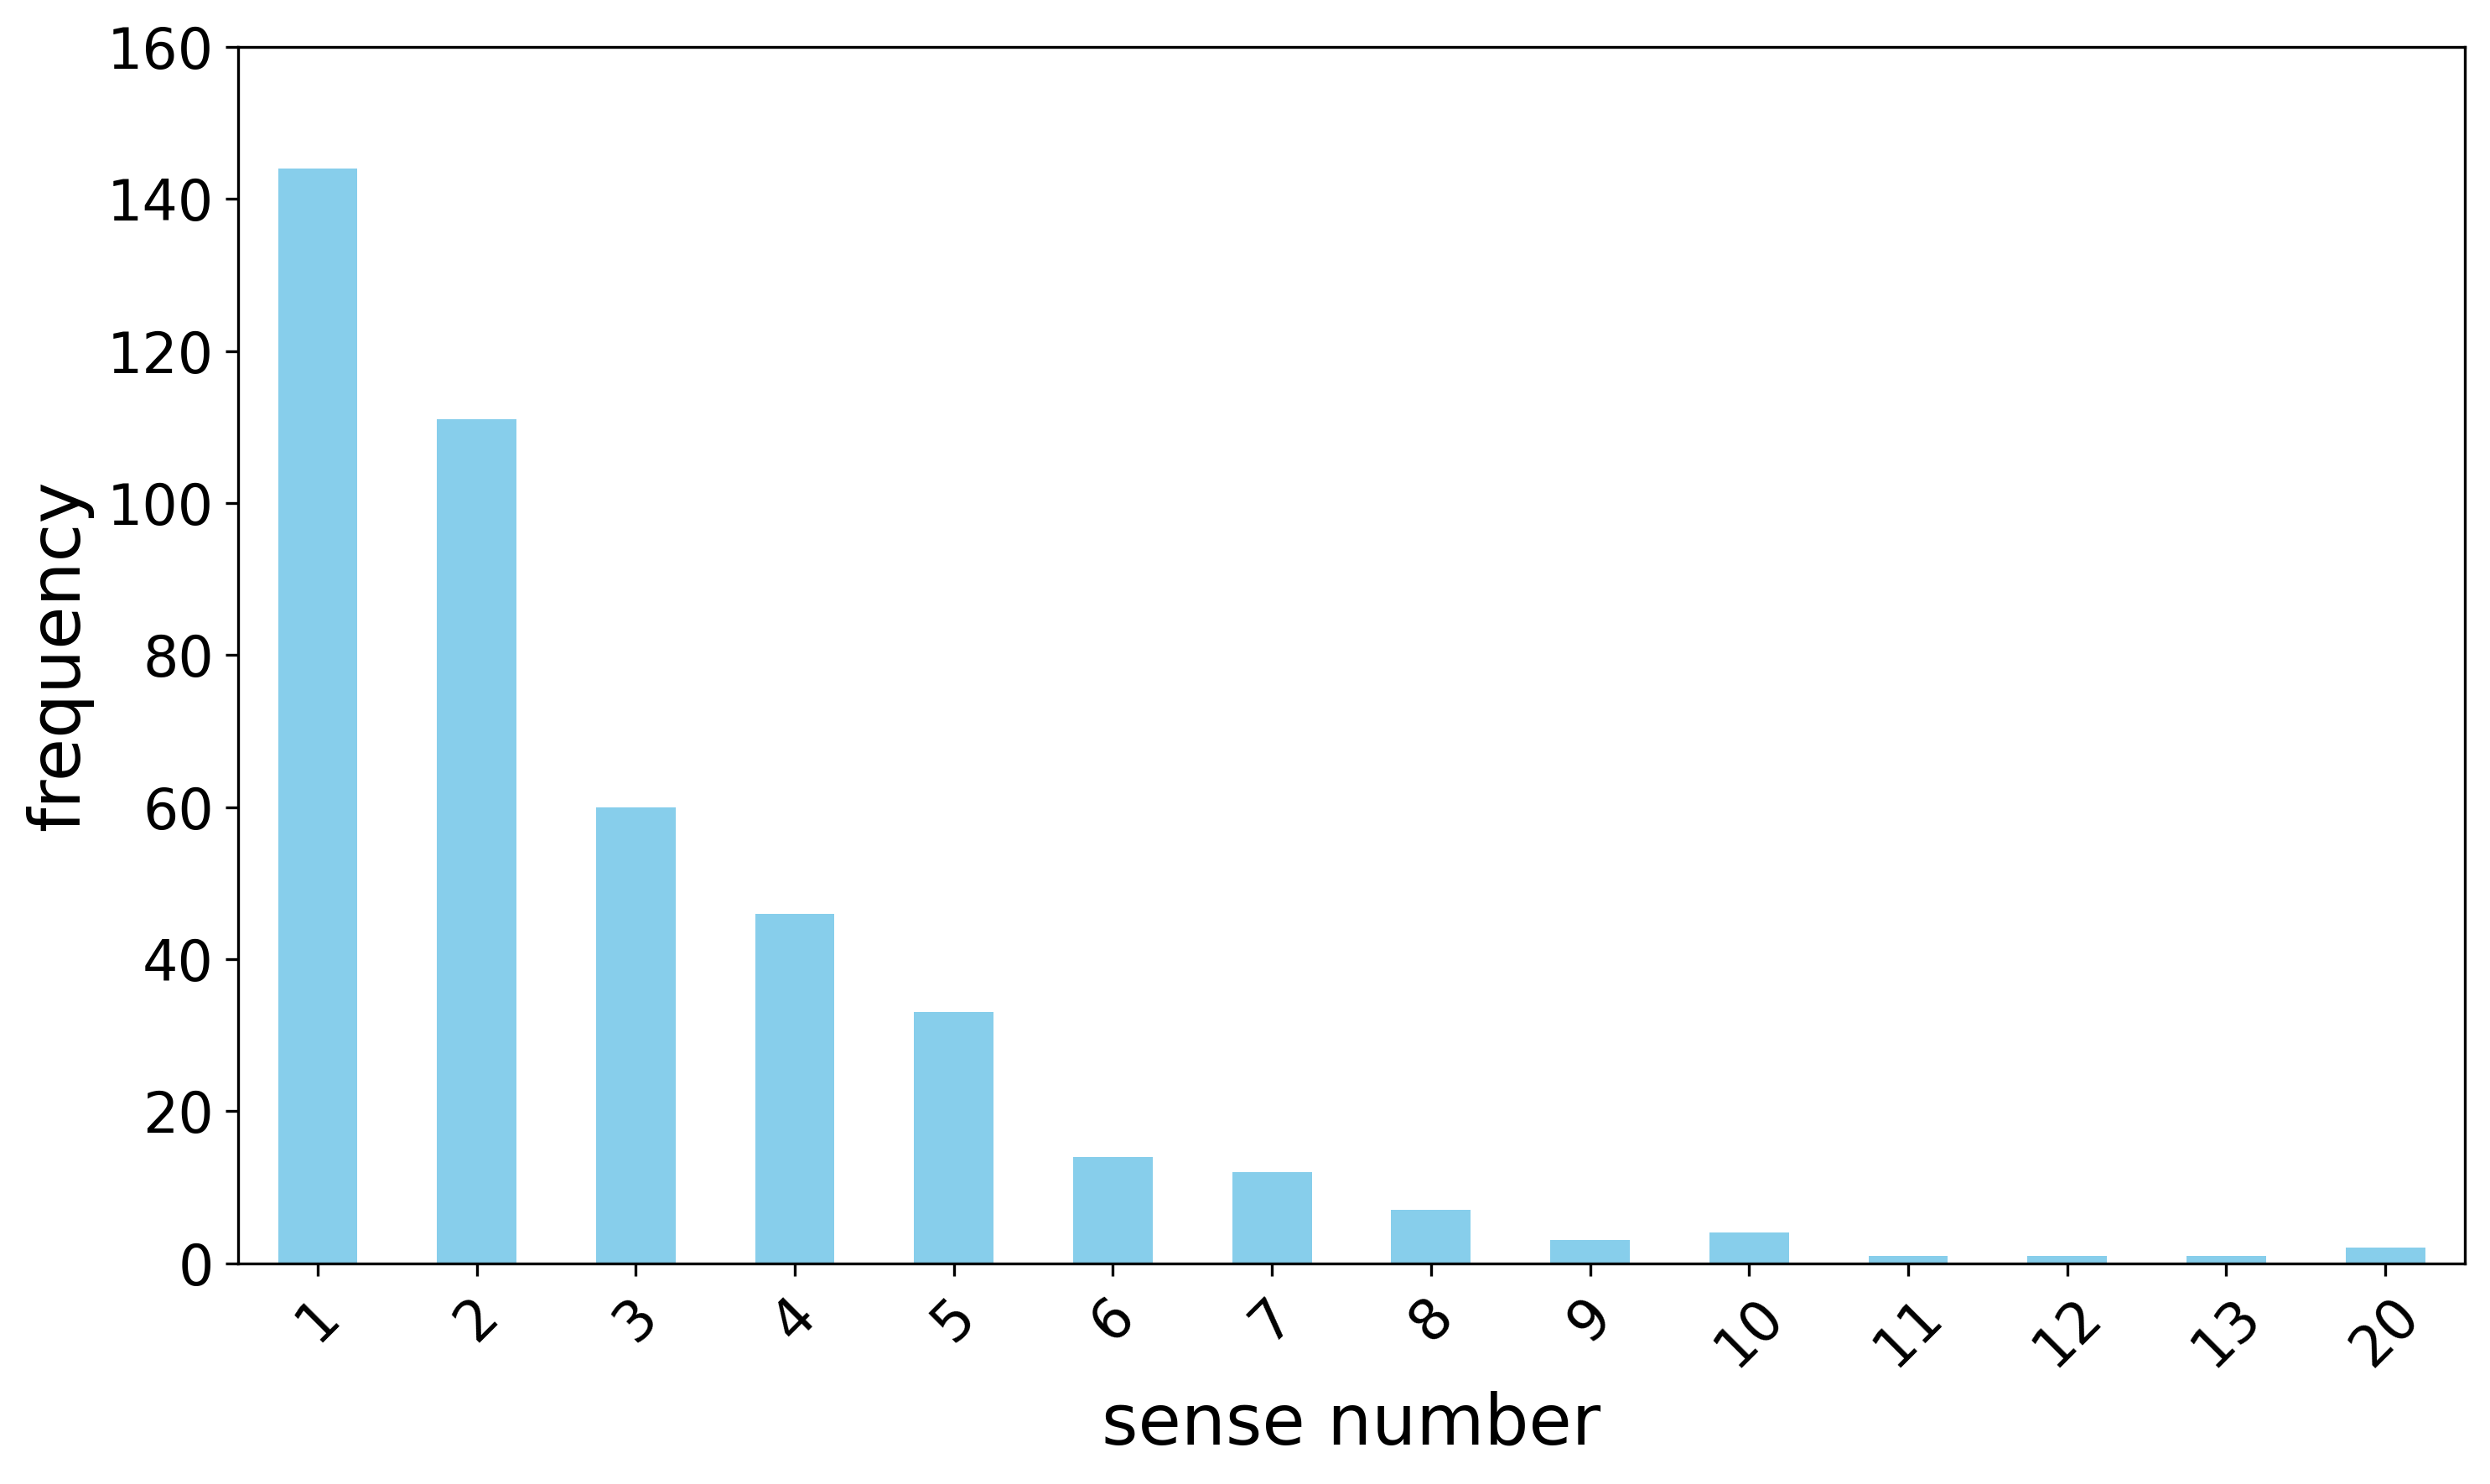

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/workspace/data/test_set_process/wsd_set_entire_labeled_ambiguous_sentence.csv")
df["gold_sense"] = df["gold_sense"].astype(int)

plt.figure(figsize=(10, 6), dpi=300)
ax = df["gold_sense"].value_counts().sort_index().plot(kind="bar", color="skyblue")
#ax.set_title("Distribution of Gold Sense Labels", fontsize=20, fontweight="bold")
ax.set_xlabel("sense number", fontsize=20)
ax.set_ylabel("frequency", fontsize=20)
ax.set_xticks(range(len(ax.get_xticklabels())), labels=ax.get_xticklabels(), rotation=45, fontsize=16)
ax.set_yticks(ax.get_yticks(), labels=ax.get_yticklabels(), fontsize=16)
plt.tight_layout()
plt.show()

Test 셋이 총 439개였으니 대충 1번으로 답하면 정답률은 32.8%. 이만큼은 깔고 가는 정확도인 셈.

In [9]:
# c만 가지고 실험을 진행하였을 때, 성능 측정
import json
import pandas as pd

dataset_df = pd.read_csv("/workspace/data/test_set_process/wsd_set_entire_labeled_ambiguous_sentence.csv")

prompt_template="""Ambiguous Word: {word}
---
Sense List:
{sense_list}
---
You are an expert linguistic annotator. A specific target word related to the given image context, and a list of potential senses for that word are provided. Your task is to determine the correct sense by selecting the one that most directly aligns with the context.
---
Decision Logic & Rules
Follow these rules in order of priority to make your decision:

Directness of Meaning: Choose the sense that provides the most direct and specific fit for the visual context. Even if a perfect match does not exist, select the sense that is the closest indirect match.
---
After all your reasoning is finished, provide your final decision as the format 'A: [sense number]' and end your generation. In here, [sense number] is the index of your chosen sense from the provided list.
"""

for index, row in dataset_df.iterrows():
    word = row["word"]
    sense_dict = json.loads(row["senses"])
    sense_list = sense_dict.get(row["gold_pos"], [])
    prompt = prompt_template.format(
        word=row["word"],
        sense_list="\n".join([f" {idx + 1}. {sense}" for idx, sense in enumerate(sense_list)]),
    )
    dataset_df.at[index, "prompt"] = prompt

dataset_df.to_csv("/workspace/data/test_set_process/wsd_set_entire_labeled_image_sense_prompt.csv", index=False)

In [11]:
import pandas as pd
result_df = pd.read_csv("/workspace/data/test_set_process/inference/wsd_set_entire_labeled_image_sense_gemma-3-27b-it.csv")


for index, row in result_df.iterrows():
    pred_label = row["generated_text"].split("A:")[-1].strip().lower()
    try:
        mapped_label = int(pred_label)
        result_df.at[index, "predicted_label"] = mapped_label
    except:
        result_df.at[index, "predicted_label"] = -1

acc = (result_df["predicted_label"] == result_df["gold_sense"]).sum() / len(result_df)
print(acc)

0.929384965831435
